### Step 1: Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

### Step 2: Load Dataset

In [4]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Step 3: Explore Dataset

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Step 4: Select Features for Clustering

In [8]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


### Step 5: Scale the Data

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Step 6: Determine Optimal Number of Clusters using Elbow Method

In [10]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

### Step 7: Visualize Elbow Method

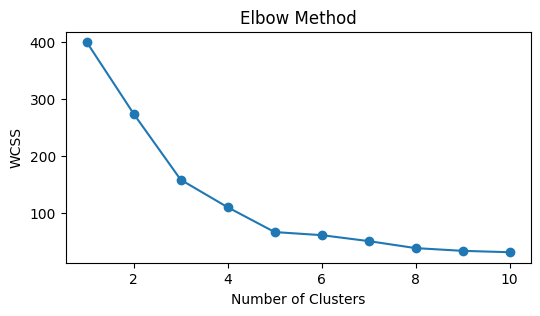

In [28]:
plt.figure(figsize=(6,3))
plt.savefig("elbow_method.png", bbox_inches="tight")

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")


plt.show()

### Step 8: Apply K-Means Clustering

In [14]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

### Step 9: Visualize K-Means Clusters

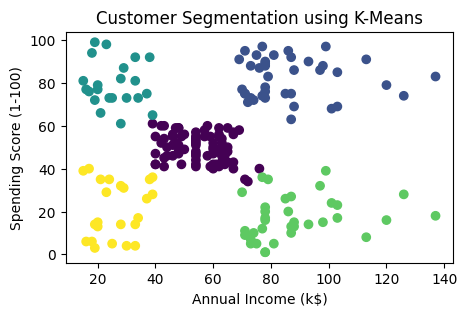

In [16]:
plt.figure(figsize=(5,3))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

### Step 10: Analyze Clusters

In [17]:
cluster_summary = df.groupby(
    'Cluster'
).mean(numeric_only=True)

cluster_summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


### Step 11: Business Insights

Cluster 0

High Income + High Spending

Customer Type: Premium Customers

Recommendation: VIP memberships and exclusive offers.

Cluster 1

High Income + Low Spending

Customer Type: Potential Customers

Recommendation: Personalized promotions.

Cluster 2

Low Income + High Spending

Customer Type: Value-Oriented Customers

Recommendation: Discount campaigns.

Cluster 3

Low Income + Low Spending

Customer Type: Occasional Customers

Recommendation: Customer engagement programs.

Cluster 4

Medium Income + Medium Spending

Customer Type: Regular Customers

Recommendation: Loyalty rewards.

### Step 12: Perform Hierarchical Clustering

In [19]:
linked = linkage(
    X_scaled,
    method='ward'
)

### Step 13: Create Dendrogram

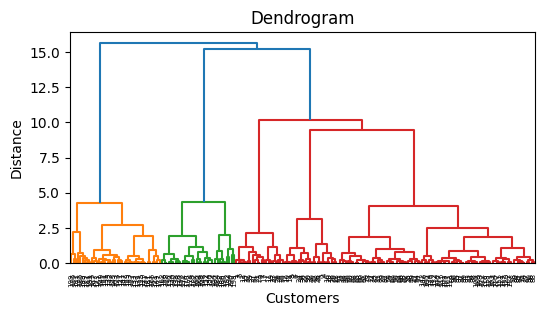

In [22]:
plt.figure(figsize=(6,3))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

### Step 14: Apply Agglomerative Clustering

In [23]:
hc = AgglomerativeClustering(
    n_clusters=5
)

df['HC_Cluster'] = hc.fit_predict(
    X_scaled
)

### Step 15: Visualize Hierarchical Clusters

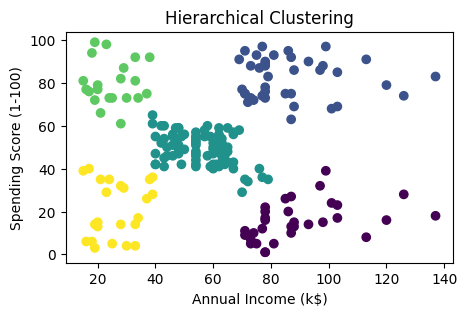

In [24]:
plt.figure(figsize=(5,3))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['HC_Cluster']
)

plt.title(
    "Hierarchical Clustering"
)

plt.xlabel(
    "Annual Income (k$)"
)

plt.ylabel(
    "Spending Score (1-100)"
)

plt.show()

### Step 16: Compare K-Means and Hierarchical Clustering

| Criteria       | K-Means      | Hierarchical |
| -------------- | ------------ | ------------ |
| Speed          | Fast         | Slower       |
| Scalability    | High         | Low          |
| Interpretation | Easy         | Detailed     |
| Visualization  | Scatter Plot | Dendrogram   |


### Step 17: Conclusion

The Mall Customers dataset was segmented using K-Means and Hierarchical Clustering techniques.

The Elbow Method identified 5 as the optimal number of clusters.

Both algorithms successfully grouped customers with similar spending behavior and income levels.

These customer segments can be used to develop targeted marketing strategies, improve customer retention, and increase business revenue.